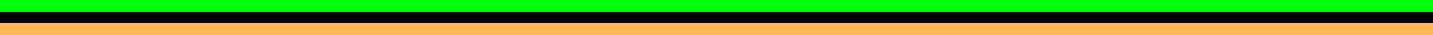

# <center> <span style='color: DARKBLUE' text-align ='center' > AI ENABLED SOFTWARE EFFORD ESTIMATION </span> </center>

v10: is a completed solution
v11: added some EDA visuals
v12: improvements according to reviewer comments

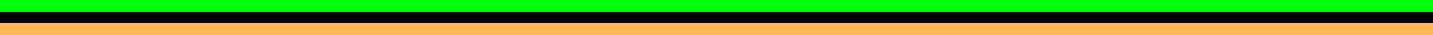

In [1]:
import os 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lars
from sklearn.linear_model import LassoLars
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import ARDRegression
from sklearn.linear_model import TweedieRegressor
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import HuberRegressor
from sklearn.linear_model import TheilSenRegressor
from sklearn.linear_model import QuantileRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

In [3]:
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV, KFold

In [4]:
from sklearn.metrics import make_scorer
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
from sklearn.metrics import max_error
from sklearn.metrics import explained_variance_score

In [5]:
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_excel("COST_ESTIMATION_TRAINING_DATASET - DISTINCT.xlsx")
df = df.drop(['Name'],axis=1)
df.loc[df['Number of data sets'].isnull(),'Number of data sets'] = 1

(39, 150)


<Axes: >

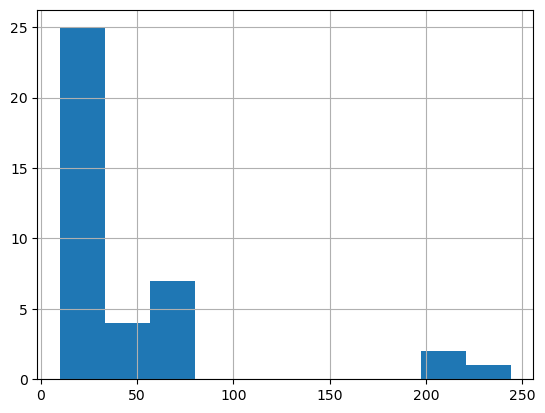

In [7]:
print(df.shape)
df.y.hist()

In [8]:
df.columns.to_list()

['VISUALIZATION',
 'SAMPLING',
 'DATA CLEANSING & PREP',
 'NEW FEATURES',
 'SPLITTING',
 'ADDITIONAL MODELS',
 'TRAINING',
 'HYPERPARAMETER TUNING',
 'CALIBRATION',
 'MODEL VALIDATION',
 'TESTING',
 'PERFORMANCE MEASUREMENT',
 'PIPELINE DEVELOPMENT',
 'TOTAL CFP',
 'y',
 'Number of data sources',
 'Number of data sets',
 'Number of rows',
 'Number of columns',
 'Number of new features',
 'Machine Learning',
 'Natural Language Processing',
 'Computer Vision',
 'Audio Processing',
 'Other',
 'Federated Learning',
 'Few shot Learning',
 'Active Learning',
 'Transfer Learning',
 'Ensemble Learning',
 'Deep Learning',
 'Text classification',
 'Information retrieval',
 'Information extraction',
 'Syntactic analysis (parsing)',
 'Machine translation',
 'Early image processing operations',
 'Object recognition by appearance',
 'Reconstructing the 3D world',
 'Object recognition from structural inf',
 'Speech recognition',
 'Explanatory Model',
 'Resampling (cross validation/bootstrap)',
 'Regu

<Axes: >

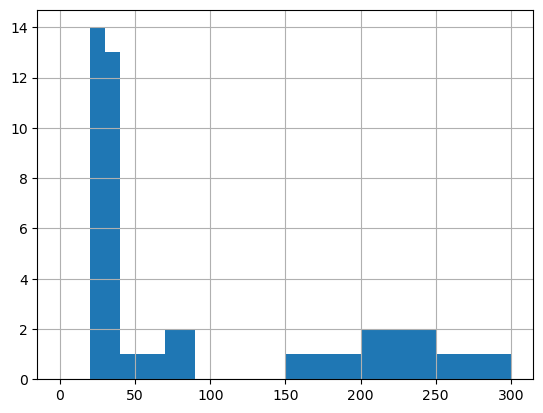

In [9]:
df['TOTAL CFP'].hist(bins=list(range(0,100,10)) + list(range(100,350,50)))

<Axes: >

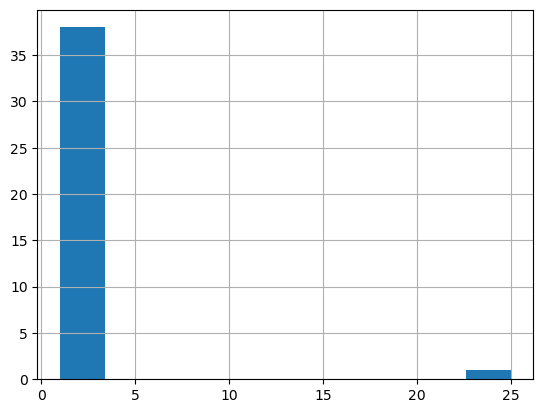

In [10]:
df['Number of data sources'].hist()

<Axes: >

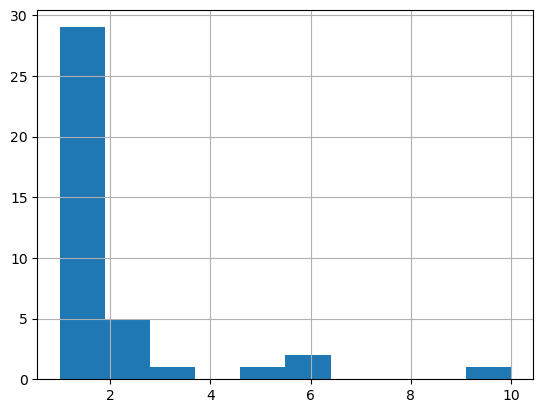

In [11]:
df['Number of data sets'].hist()

<Axes: >

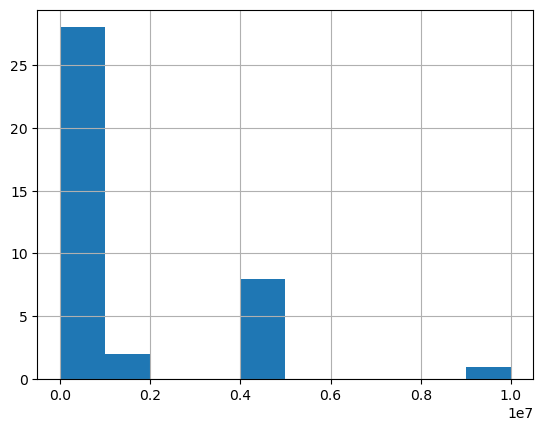

In [12]:
df['Number of rows'].hist()

<Axes: >

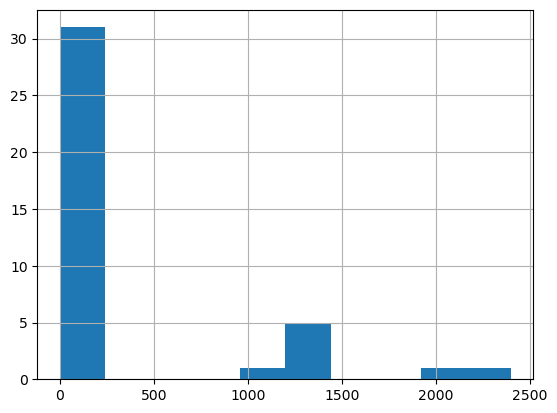

In [13]:
df['Number of columns'].hist()

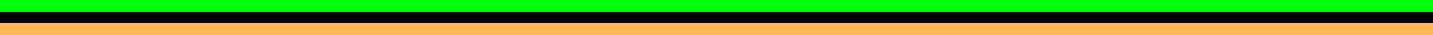

In [14]:
df[df.columns[df.dtypes == 'category']] = df[df.columns[df.dtypes == 'category']].astype(object)
df = df.fillna(0)
df = pd.get_dummies(df, columns=df.columns[df.dtypes == object])
df.head(3)

,VISUALIZATION,SAMPLING,DATA CLEANSING & PREP,NEW FEATURES,SPLITTING,ADDITIONAL MODELS,TRAINING,HYPERPARAMETER TUNING,CALIBRATION,MODEL VALIDATION,...,Pseudomization,K Anonimity,Differential privacy,Secure multiparty computation,Encryption,Permutation Feature Importance,SHAPley values,LIME,Partial Dependence Plots (PDPs),Individual Conditional Expectation (ICE) Plots
0,2,0,2,0,0,0,10,0,0,3,...,False,False,False,False,False,False,False,False,False,False
1,2,0,2,0,0,0,10,0,0,3,...,False,False,False,False,False,False,False,False,False,False
2,2,0,2,0,0,0,10,0,0,3,...,False,False,False,False,False,False,False,False,False,False


In [15]:
df.isnull().sum().sum()
#df = df.replace(np.nan,0) #NOT NEEDED

0

In [16]:
df['C_Model_components'] = df['Explanatory Model'] + df['Resampling (cross validation/bootstrap)'] + df['Regularization (shrinkage)'] + \
                        df['Automated machine learning'] + df['Real-time scoring'] + df['Content-based filtering'] + df['Collaborative filtering'] + \
                        df['Survival analysis'] + df['Network analysis'] + df['Text Mining'] + df['Time Series Analysis']
df = df.drop(['Explanatory Model','Resampling (cross validation/bootstrap)','Regularization (shrinkage)','Automated machine learning','Real-time scoring',
              'Content-based filtering','Collaborative filtering','Survival analysis','Network analysis','Text Mining','Time Series Analysis'],axis=1)

In [17]:
df['C_Environment'] = df['Flat File'] + df['RDBMS'] + df['Hadoop'] + df['Spark'] + df['Github'] + df['Jupyter']
df = df.drop(['Flat File','RDBMS','Hadoop','Spark','Github','Jupyter'],axis=1)

In [18]:
df['C_Languages'] = df['Python'] + df['SQL'] + df['R'] + df['Scala'] + df['MapReduce'] + df['C'] + df['C++'] + \
                    df['Java'] + df['Java Script'] + df['Other_1']
df = df.drop(['Python','SQL','R','Scala','MapReduce','C','C++','Java','Java Script','Other_1'],axis=1)

In [19]:
df['C_Additional_models'] = df['Baseline model'] + df['Explainer model'] + df['Association analysis'] + df['Clustering'] + \
                          df['Dimensionality Reduction'] + df['Pattern recognition'] + df['Sequence analysis'] + df['Anomaly detection']
df = df.drop(['Baseline model','Explainer model','Association analysis','Clustering','Dimensionality Reduction','Pattern recognition',
              'Sequence analysis','Anomaly detection'],axis=1)

In [20]:
df['C_Misclassification'] = df['Single misclassification cost'] + 2*df['Class based misclassification cost'] + 4*df['Heteregeneous misclassification cost']
df = df.drop(['Single misclassification cost','Class based misclassification cost','Heteregeneous misclassification cost'],axis=1)

In [21]:
df['C_Custom Algorithm'] = 1*df['Metaheuristic usage'] + 2*df['Heuristic algorithm development']
df = df.drop(['Metaheuristic usage','Heuristic algorithm development'],axis=1)

In [22]:
df['C_Algorithms'] = df['Linear Regression'] + df['Logistics Regression'] + df['Polynomial Regression'] + df['Other Regression'] + df['Decision Trees'] + \
                   df['Random Forest'] + df['Gradient Boosting'] + df['XGBoost'] + df['Ada Boost'] + df['Naive Bayes'] + df['Nearest Neighboor'] + \
                   df['Support Vector Machines'] + df['Artificial Neural Networks'] + df['Other Algorithms']
df = df.drop(['Linear Regression','Logistics Regression','Polynomial Regression','Other Regression','Decision Trees','Random Forest',
                            'Gradient Boosting','XGBoost','Ada Boost','Naive Bayes','Nearest Neighboor','Support Vector Machines',
                            'Artificial Neural Networks','Other Algorithms'],axis=1)

In [23]:
df['C_Balanced'] = 1*df['Balanced dataset'] + 2*df['Imbalanced dataset'] + 4*df['Rare event dataset']
df = df.drop(['Balanced dataset','Imbalanced dataset','Rare event dataset'],axis=1)

In [24]:
df['C_Sampling'] = 2*df['Oversampling'] + 2*df['Undersampling'] + 1*df['Random Sampling'] + 2*df['Stratified sampling'] + 0*df['No sampling']
df = df.drop(['Oversampling','Undersampling','Random Sampling','Stratified sampling','No sampling'],axis=1)

In [25]:
df['C_Data_Prep'] = df['Missing value imputation'] + df['Missing value imputation with model'] + df['Outlier detection & removal'] + \
                  df['Scaling (Min-max and normalization)'] + df['Binning'] + df['Basic transformations'] + df['Smoothing'] + \
                  df['Trimming/Clipping'] + df['Text Preprocessing']
df = df.drop(['Missing value imputation','Missing value imputation with model','Outlier detection & removal','Scaling (Min-max and normalization)',
              'Binning','Basic transformations','Smoothing','Trimming/Clipping','Text Preprocessing'],axis=1)

In [26]:
df['C_Feature_Engineering'] = 1*df['Basic aggregations'] + 2*df['Extended aggregations'] + 2*df['Linearization'] + 4*df['Composite features'] + \
                              2*df['Variable grouping'] + 1*df['Dummy variables'] + 2*df['Feature extraction from unstructured data'] + \
                              4*df['Advanced feature engineering'] 
df = df.drop(['Basic aggregations','Extended aggregations','Linearization','Composite features','Variable grouping','Dummy variables',
              'Feature extraction from unstructured data','Advanced feature engineering'],axis=1)

In [27]:
df['C_Splitting'] = 1*df['Train/Test'] + 2*df['Complex Splitting']
df = df.drop(['Train/Test','Complex Splitting'],axis=1)

In [28]:
df['C_Visualization'] = 1*df['Basic visualization'] + 2*df['Basic with profiling'] + 4*df['Extended visualization'] + 8*df['Extended + storytelling']
df = df.drop(['Basic visualization','Basic with profiling','Extended visualization','Extended + storytelling'],axis=1)

In [29]:
df['C_Performance'] = df['Minimum PM'] + df['Basic PM'] + df['Intermediate PM'] + df['Extended PM'] + df['Extended & automated PM']
df = df.drop(['Minimum PM','Basic PM','Intermediate PM','Extended PM','Extended & automated PM'],axis=1)

In [30]:
df['C_Calibration'] = df['Conversion to probabilities'] + df['Calibration for undersampling']
df = df.drop(['Conversion to probabilities','Calibration for undersampling'],axis=1)

In [31]:
df['C_Validation'] = 1*df['Basic validation'] + 2*df['Extended validation'] + 4*df['Regulator defined validation']
df = df.drop(['Basic validation','Extended validation','Regulator defined validation'],axis=1)

In [32]:
df['C_Tuning'] = 1*df['Grid Search'] + 1*df['Random Search'] + 2*df['Optimization methods']
df = df.drop(['Grid Search','Random Search','Optimization methods'],axis=1)

In [33]:
df['C_Privacy'] = 1*df['Anonymization'] + 2*df['Pseudomization'] + 2*df['K Anonimity'] + 4*df['Differential privacy'] + \
                  4*df['Secure multiparty computation'] + 4*df['Encryption']
df = df.drop(['Anonymization','Pseudomization','K Anonimity','Differential privacy','Secure multiparty computation','Encryption'],axis=1)

In [34]:
df['C_Explainability'] = df['Permutation Feature Importance'] + df['SHAPley values'] + df['LIME'] + \
                         df['Partial Dependence Plots (PDPs)'] + df['Individual Conditional Expectation (ICE) Plots']
df = df.drop(['Permutation Feature Importance','SHAPley values','LIME',
              'Partial Dependence Plots (PDPs)','Individual Conditional Expectation (ICE) Plots'],axis=1)

In [35]:
print(df.shape)
df_Var = pd.DataFrame(df.var(),columns=['variance'])
print(len(df_Var.loc[df_Var['variance']<0.05,:].index))
print(df_Var.loc[df_Var['variance']<0.05,:].index)
df = df.drop(df_Var.loc[df_Var['variance']<0.05,:].index.to_list(),axis=1)
print(df.shape)

(39, 60)
20
Index(['Computer Vision', 'Audio Processing', 'Other', 'Federated Learning',
       'Few shot Learning', 'Active Learning', 'Transfer Learning',
       'Ensemble Learning', 'Deep Learning', 'Information retrieval',
       'Machine translation', 'Early image processing operations',
       'Object recognition by appearance', 'Reconstructing the 3D world',
       'Object recognition from structural inf', 'Speech recognition',
       'C_Languages', 'C_Performance', 'C_Privacy', 'C_Explainability'],
      dtype='object')
(39, 40)


In [36]:
df.shape, len(df.columns[df.dtypes == bool]), len(df.columns[df.dtypes != bool])

((39, 40), 11, 29)

In [37]:
df.columns

Index(['VISUALIZATION', 'SAMPLING', 'DATA CLEANSING & PREP', 'NEW FEATURES',
       'SPLITTING', 'ADDITIONAL MODELS', 'TRAINING', 'HYPERPARAMETER TUNING',
       'CALIBRATION', 'MODEL VALIDATION', 'TESTING', 'PERFORMANCE MEASUREMENT',
       'PIPELINE DEVELOPMENT', 'TOTAL CFP', 'y', 'Number of data sources',
       'Number of data sets', 'Number of rows', 'Number of columns',
       'Number of new features', 'Machine Learning',
       'Natural Language Processing', 'Text classification',
       'Information extraction', 'Syntactic analysis (parsing)',
       'C_Model_components', 'C_Environment', 'C_Additional_models',
       'C_Misclassification', 'C_Custom Algorithm', 'C_Algorithms',
       'C_Balanced', 'C_Sampling', 'C_Data_Prep', 'C_Feature_Engineering',
       'C_Splitting', 'C_Visualization', 'C_Calibration', 'C_Validation',
       'C_Tuning'],
      dtype='object')

In [38]:
y = df['y']
X_original = df.drop('y',axis=1)
X_original.shape

(39, 39)

In [39]:
# make standard scaling
X_scaled = X_original.copy()
for c in X_scaled.columns[X_original.dtypes != object]:
    #scaler = preprocessing.StandardScaler()
    scaler = preprocessing.MinMaxScaler()
    xx = np.array(X_original[c]).reshape(-1, 1)
    scaler.fit(xx)
    X_scaled[c] = scaler.transform(xx)
X = X_scaled

In [40]:
# using scaled input features create train and test datasets with 70% of the rows at training dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1923)
model = RandomForestRegressor(n_estimators=1000,random_state=1923,min_samples_leaf=5)
model.fit(X_train,y_train)
feat = pd.DataFrame(model.feature_importances_,columns=['Importance'])
feat['feature'] = X_train.columns
best_features = feat.nlargest(9,'Importance')['feature'].to_list()
best_features

['Number of rows',
 'Number of columns',
 'TOTAL CFP',
 'C_Additional_models',
 'ADDITIONAL MODELS',
 'C_Validation',
 'NEW FEATURES',
 'Number of new features',
 'C_Feature_Engineering']

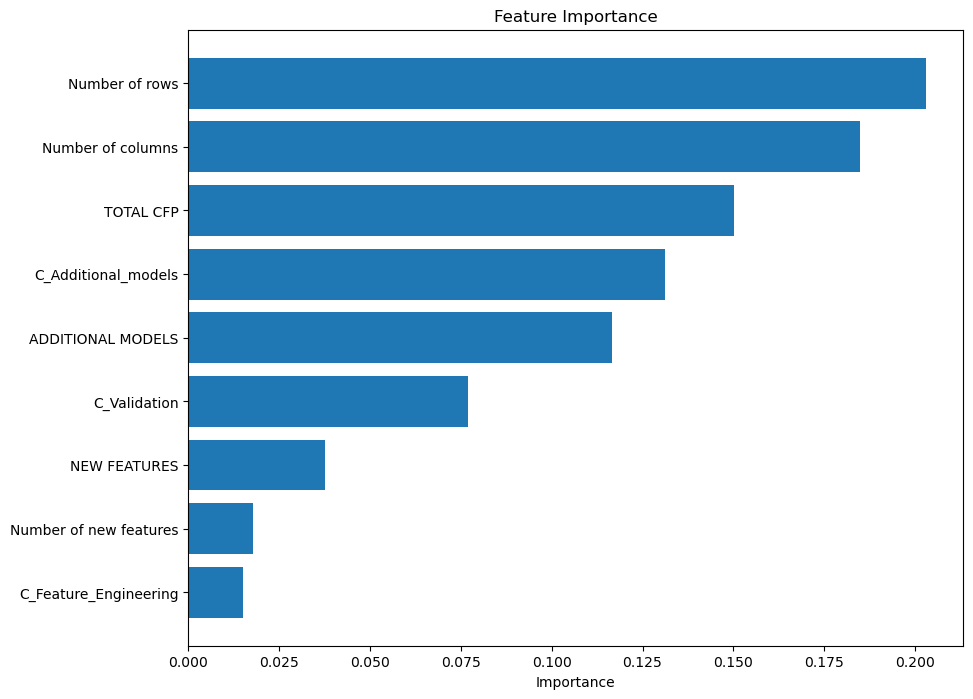

In [41]:
feat = pd.DataFrame(model.feature_importances_,index=X_test.columns,columns=['Importance'])
n = 9
feat1=feat.nlargest(n,'Importance')
plt.figure(figsize=(10,8))
plt.barh(range(n),feat1['Importance'])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.yticks(range(n),feat1.index)
plt.gca().invert_yaxis()
plt.savefig('Feature Importance.png',bbox_inches='tight')
plt.show()

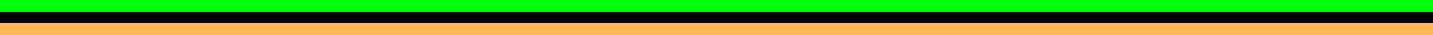

In [42]:
def MP(model_name, feature_selection, y_test, pred_test, fold, k, features):
    global Results
    NewResult = pd.DataFrame()
    NewResult.loc[0,'Model Name'] = str(model_name)
    NewResult['feature_selection'] = feature_selection
    NewResult['R2'] = r2_score(y_test, pred_test)
    NewResult['MAE'] = mean_absolute_error(y_test, pred_test)
    NewResult['MSE'] = mean_squared_error(y_test, pred_test)
    NewResult['MAPE'] = mean_absolute_percentage_error(y_test, pred_test)
    NewResult['MedianAE'] = median_absolute_error(y_test, pred_test)
    NewResult['MaxE'] = max_error(y_test, pred_test)
    NewResult['MMRE'] = ((y_test - pred_test)/y_test).abs().mean()
    NewResult['PRED(25)'] = np.where(((y_test - pred_test)/y_test).abs()<0.25,1,0).mean()
    NewResult['fold'] = fold
    NewResult['k'] = k
    features.sort()
    NewResult['features'] = ', '.join(features)
    Results = pd.concat([Results, NewResult]).reset_index(drop=True)

In [43]:
Regressors = pd.DataFrame(columns=['Regressor','RFE'])
Regressors.loc[0,:] = [DummyRegressor(strategy="mean"),False]
Regressors.loc[1,:] = [DummyRegressor(strategy="median"),False]
Regressors.loc[2,:] = [LinearRegression(),True]
Regressors.loc[3,:] = [Ridge(),True]
Regressors.loc[4,:] = [Lasso(),True]
Regressors.loc[5,:] = [ElasticNet(),True]
Regressors.loc[6,:] = [Lars(),False]
Regressors.loc[7,:] = [LassoLars(),True]
Regressors.loc[8,:] = [OrthogonalMatchingPursuit(),True]
Regressors.loc[9,:] = [ARDRegression(),True]
Regressors.loc[10,:] = [BayesianRidge(),True]
Regressors.loc[11,:] = [TweedieRegressor(),True]
Regressors.loc[12,:] = [RANSACRegressor(min_samples=5),False]
Regressors.loc[13,:] = [HuberRegressor(),False]
Regressors.loc[14,:] = [TheilSenRegressor(),True]
Regressors.loc[15,:] = [QuantileRegressor(),True]
Regressors.loc[16,:] = [DecisionTreeRegressor(),True]
Regressors.loc[17,:] = [KNeighborsRegressor(),False]
Regressors.loc[18,:] = [RandomForestRegressor(),True]
Regressors.loc[19,:] = [GradientBoostingRegressor(),True]
Regressors.loc[20,:] = [MLPRegressor(),False]
Regressors.loc[21,:] = [SVR(),False]

In [44]:
AllParameters = pd.DataFrame(columns=['Regressor','Argument','Values'])
AllParameters.loc[0,:] = ['Ridge()','alpha',[0.2,0.4,0.6,0.8,1.0,10]]
AllParameters.loc[1,:] = ['Lasso()','alpha',[0.2,0.4,0.6,0.8,1.0,10]]
AllParameters.loc[2,:] = ['ElasticNet()','alpha',[0.2,0.4,0.6,0.8,1.0,10]]
AllParameters.loc[3,:] = ['ElasticNet()','l1_ratio',[0.2,0.4,0.5,0.6,0.8]]
AllParameters.loc[4,:] = ['LassoLars()','alpha',[0.01,0.1,0.5,0.9,1.0,10]]
AllParameters.loc[5,:] = ['ARDRegression()','alpha_1',[0.000001,0.0001,0.01]]
AllParameters.loc[6,:] = ['ARDRegression()','alpha_2',[0.000001,0.0001,0.01]]
AllParameters.loc[7,:] = ['ARDRegression()','lambda_1',[0.000001,0.0001,0.01]]
AllParameters.loc[8,:] = ['ARDRegression()','lambda_2',[0.000001,0.0001,0.01]]
AllParameters.loc[9,:] = ['BayesianRidge()','alpha_1',[0.000001,0.0001,0.01]]
AllParameters.loc[10,:] = ['BayesianRidge()','alpha_2',[0.000001,0.0001,0.01]]
AllParameters.loc[11,:] = ['BayesianRidge()','lambda_1',[0.000001,0.0001,0.01]]
AllParameters.loc[12,:] = ['BayesianRidge()','lambda_2',[0.000001,0.0001,0.01]]
AllParameters.loc[13,:] = ['TweedieRegressor()','power',[0,1,2,3]]
AllParameters.loc[14,:] = ['TweedieRegressor()','alpha',[0,1,10,100]]
AllParameters.loc[15,:] = ['RANSACRegressor(min_samples=5)','loss',['absolute_error','squared_error']]
AllParameters.loc[16,:] = ['HuberRegressor()','alpha',[0.2,0.4,0.6,0.8,1.0,10]]
AllParameters.loc[17,:] = ['QuantileRegressor()','quantile',[0.25,0.5,0.75]]
AllParameters.loc[18,:] = ['QuantileRegressor()','alpha',[0.01,0.1,0.5,0.9,1.0]]
AllParameters.loc[19,:] = ['DecisionTreeRegressor()','criterion',['squared_error','friedman_mse','absolute_error','poisson']]
AllParameters.loc[20,:] = ['DecisionTreeRegressor()','min_samples_leaf',[1,5,10,20,30]]
AllParameters.loc[21,:] = ['DecisionTreeRegressor()','ccp_alpha',[0,0.1]]
AllParameters.loc[22,:] = ['KNeighborsRegressor()','n_neighbors',[3,5,10]]
AllParameters.loc[23,:] = ['KNeighborsRegressor()','weights',["uniform", "distance"]]
AllParameters.loc[24,:] = ['KNeighborsRegressor()','metric',["euclidean", "manhattan", "chebyshev", "minkowski"]]
AllParameters.loc[25,:] = ['RandomForestRegressor()','n_estimators',[50,100,200]]
AllParameters.loc[26,:] = ['RandomForestRegressor()','criterion',['squared_error','friedman_mse','absolute_error','poisson']]
AllParameters.loc[27,:] = ['RandomForestRegressor()','min_samples_leaf',[1,5,10,20,30]]
AllParameters.loc[28,:] = ['RandomForestRegressor()','ccp_alpha',[0,0.1]]
AllParameters.loc[29,:] = ['GradientBoostingRegressor()','loss',['squared_error','absolute_error','huber','quantile']]
AllParameters.loc[30,:] = ['GradientBoostingRegressor()','learning_rate',[0.1,0.5]]
AllParameters.loc[31,:] = ['GradientBoostingRegressor()','criterion',['squared_error','friedman_mse']]
AllParameters.loc[32,:] = ['GradientBoostingRegressor()','min_samples_leaf',[1,5,10,20,30]]
AllParameters.head(3)

,Regressor,Argument,Values
0,Ridge(),alpha,"[0.2, 0.4, 0.6, 0.8, 1.0, 10]"
1,Lasso(),alpha,"[0.2, 0.4, 0.6, 0.8, 1.0, 10]"
2,ElasticNet(),alpha,"[0.2, 0.4, 0.6, 0.8, 1.0, 10]"


In [45]:
X = df.drop('y',axis=1)
y = df['y']
Results = pd.DataFrame()
for i in range(len(Regressors)):
    print(Regressors.Regressor[i])
    for k in range(20):
        kf = KFold(n_splits=5,shuffle=True,random_state=k)
        kf.get_n_splits()
        for fold, (train_index, test_index) in enumerate(kf.split(X)):
            X_train = X.loc[train_index,:]
            y_train = y[train_index]
            X_test = X.loc[test_index,:]
            y_test = y[test_index]
            My_Model_best = Regressors.Regressor[i].fit(X_train[best_features], y_train)
            pred_test_best = My_Model_best.predict(X_test[best_features])
            MP(Regressors.Regressor[i], 'Best', y_test, pred_test_best, fold, k, best_features)
            if Regressors.RFE[i]==True:
                selector = RFE(Regressors.Regressor[i], n_features_to_select=9, step=1)
                selector = selector.fit(X_train, y_train)
                pred_test = selector.predict(X_test)
                MP(Regressors.Regressor[i], 'RFESel', y_test, pred_test, fold, k, X_train[selector.get_feature_names_out()].columns.to_list())
            if len(AllParameters.loc[AllParameters.Regressor==str(Regressors.Regressor[i]),:])>0:
                AllParameters.loc[AllParameters.Regressor==str(Regressors.Regressor[i]),['Argument','Values']].set_index('Argument')['Values'].to_dict()
                my_scorer = make_scorer(mean_absolute_percentage_error)
                param_grid = AllParameters.loc[AllParameters.Regressor==str(Regressors.Regressor[i]),['Argument','Values']].set_index('Argument')['Values'].to_dict()
                grid = GridSearchCV(Regressors.Regressor[i], param_grid, cv=5, scoring=my_scorer)
                if Regressors.RFE[i]==True:
                    features_to_be_used = selector.get_feature_names_out()
                else:
                    features_to_be_used = best_features
                grid.fit(X_train[features_to_be_used], y_train)
                best_classifier = grid.best_estimator_
                pred_test = best_classifier.predict(X_test[features_to_be_used])
                MP(Regressors.Regressor[i], 'GridCV', y_test, pred_test, fold, k, X_train[features_to_be_used].columns.to_list())


DummyRegressor()
DummyRegressor(strategy='median')
LinearRegression()
Ridge()
Lasso()
ElasticNet()
Lars()
LassoLars()
OrthogonalMatchingPursuit()
ARDRegression()
BayesianRidge()
TweedieRegressor()
RANSACRegressor(min_samples=5)
HuberRegressor()
TheilSenRegressor()
QuantileRegressor()
DecisionTreeRegressor()
KNeighborsRegressor()
RandomForestRegressor()
GradientBoostingRegressor()
MLPRegressor()
SVR()


In [46]:
Results.head()

,Model Name,feature_selection,R2,MAE,MSE,MAPE,MedianAE,MaxE,MMRE,PRED(25),fold,k,features
0,DummyRegressor(),Best,-0.050270,21.000000,489.163111,1.004637,16.161290,31.838710,1.004637,0.000000,0,0,"ADDITIONAL MODELS, C_Additional_models, C_Feat..."
1,DummyRegressor(),Best,-2.048392,23.500000,610.250000,1.296458,22.500000,37.000000,1.296458,0.125000,1,0,"ADDITIONAL MODELS, C_Additional_models, C_Feat..."
2,DummyRegressor(),Best,-0.000452,42.415323,3706.784729,1.578408,28.580645,157.419355,1.578408,0.000000,2,0,"ADDITIONAL MODELS, C_Additional_models, C_Feat..."
3,DummyRegressor(),Best,-0.207030,57.064516,9100.324662,1.030784,22.741935,209.258065,1.030784,0.375000,3,0,"ADDITIONAL MODELS, C_Additional_models, C_Feat..."
4,DummyRegressor(),Best,-0.907075,22.558036,636.340262,1.563408,20.968750,35.968750,1.563408,0.285714,4,0,"ADDITIONAL MODELS, C_Additional_models, C_Feat..."


In [47]:
Results['Model Name & Sel & Tune'] = Results['Model Name'] + Results['feature_selection']
Results.groupby(['Model Name & Sel & Tune']).agg({'MAE': 'mean'}).sort_values(by='MAE').head()

,MAE
Model Name & Sel & Tune,
DecisionTreeRegressor()RFESel,17.558750
GradientBoostingRegressor()Best,17.842367
KNeighborsRegressor()GridCV,18.293927
GradientBoostingRegressor()RFESel,18.824688
RandomForestRegressor()Best,19.487598


In [48]:
Results.groupby(['Model Name & Sel & Tune']).agg({'MMRE': 'mean'}).sort_values(by='MMRE').head()

,MMRE
Model Name & Sel & Tune,
DecisionTreeRegressor()RFESel,0.374783
KNeighborsRegressor()GridCV,0.413299
GradientBoostingRegressor()RFESel,0.449661
RandomForestRegressor()RFESel,0.487896
GradientBoostingRegressor()Best,0.497862


In [49]:
Results.to_excel('Results-DISTINCT.xlsx')

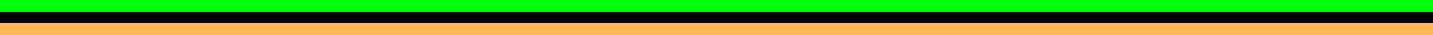